# Bipolar narratives in Evergreen_v5: do the two poles discriminate?

**Question.** Evergreen_v5 encodes 51 bipolar narratives: two narratives in the same
`TOPIC/GROUP/TYPE` that differ only by `SUB_TYPE` (e.g. `earnings-beat` / `earnings-miss`,
`rating-upgrade` / `rating-downgrade`). The scorer treats each pole as its own narrative. Here we
test whether the scorer actually separates the two poles, or mostly measures the shared *topic*
and splits it between them.

The GFC and Covid studies suggested the latter for part of the taxonomy: after Lehman,
`bank-balance-sheet-repair` ranked #1 and `benign-credit-environment` #6. This notebook measures
that for all 51 pairs, and **reports whatever comes out**. It is not a validation exercise.

**What "the poles discriminate" should look like, and what would count against it**

| # | Level | If the poles discriminate | Against |
|---|---|---|---|
| H1 | Daily/weekly attention (`narrative_daily`) | Pole co-movement no higher than for two unrelated narratives in the same dimension | Pole pairs co-move more than same-dimension non-pairs, i.e. both poles follow the topic |
| H2 | Known-direction episodes | The pole balance tilts the expected way (e.g. downgrades over upgrades in 2008Q4) | Balance does not move, or moves the wrong way |
| H3 | Taxonomy geometry (corrected primitive embeddings) | The two poles are no closer to each other than to other narratives of their dimension | Pole prototypes nearly coincide |
| H4 | Single headlines (re-scored sample) | A headline assigned to one pole is rarely assigned to the other; RavenPack's own event sentiment differs between poles | High co-assignment; no sentiment difference |

Thresholds used for flags are **heuristics set before looking at the results** (config cell), not
significance tests; every number behind a flag is shown.

**Limitations known in advance**
- Pairs come from the taxonomy's `TYPE`. Some are not strict antonyms (`debt-issuance` /
  `debt-repurchase`, `dividend-cut` / `dividend-initiation`). The other 84 signed narratives have no
  `TYPE` sibling and are out of scope.
- Attention (share of the flow) is compositional, so every pair shares a common component with
  every other narrative; the benchmarks below are there to net that out.
- RavenPack `EVENT_SENTIMENT_SCORE` (ESS) is an external classifier with its own errors. It is
  entity-relative, and many headlines have no ESS. It is informative only for pairs with a clear
  good-news pole (`VALENCE_GOOD`).
- The headline-level section uses ~200k headlines from ONE month (`SAMPLE_MONTH`). One month cannot
  speak for every regime; rerun with another month for robustness. It reproduces the production
  selection (same code, config, embeddings, mu and tau per day), and a reproduction check guards that.

Read-only on the datalake. The headline sample is cached under `$CACHE_PATH/narrative_scoring/`
so re-runs are cheap. The first run reads one month of headlines and embeddings: **run it when no
scoring job is running**.

In [2]:
import hashlib
import json
import os
from datetime import date, timedelta
from pathlib import Path

import duckdb
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from dotenv import find_dotenv, load_dotenv

from datalake import DatalakeIndex
from narrative_scoring.aggregation import headline_narrative_scores
from narrative_scoring.artifacts import load_registered_table
from narrative_scoring.config import ScoringConfig
from narrative_scoring.primitives import (embeddings_digest, primitive_scores, representative_matrix,
                                          scoring_matrix, texts_digest)
from narrative_scoring.schema import EMBEDDING_DIM
from narrative_scoring.selection import select
from narrative_scoring.streaming import arrow_embeddings_to_numpy
from nlp.corrections import apply_mode, l2_normalise
from nlp.reference_vector import load_reference_series, resolve_reference

load_dotenv(find_dotenv(usecwd=True))
pl.Config.set_tbl_rows(60); pl.Config.set_tbl_width_chars(230); pl.Config.set_fmt_str_lengths(70)
pl.Config.set_tbl_cols(20)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "figure.constrained_layout.use": True})

TAXONOMY = "Evergreen_v5"
NARRATIVE_DAILY_ID = None            # None = most recent narrative_daily of TAXONOMY (partial allowed)
KEY = "narrative_key"
CORR_FROM = date(2002, 1, 1)         # time-series section: skip the thin 2000-01 feed
EPS = 1e-6                           # log / logit floor on attention shares

# headline-level sample (section 5)
SAMPLE_MONTH = "2019-05"             # ONE month: bounded read of its headline + embedding files only
SAMPLE_ROWS = 200_000                # headlines drawn uniformly over that month (deterministic hash)
SAMPLE_SEED = 0
CHUNK = 4_096                        # rows per scoring block (memory: CHUNK x n_texts*P float32)
DUCKDB_THREADS = 4
CACHE_DIR = Path(os.environ["CACHE_PATH"]) / "narrative_scoring"

# flags: heuristics fixed before looking at results
FLAG_CORR_PCTL = 0.75      # pair's weekly-change corr above this percentile of same-dimension non-pairs
FLAG_COASSIGN = 0.30       # max(P(B|A), P(A|B)) above this in the headline sample
FLAG_COS_PCTL = 0.90       # pole-prototype cosine above this percentile of same-dimension non-pairs
FLAG_AUC = 0.55            # valence-oriented ESS AUC below this = no external direction signal
MIN_HEADLINES = 50         # per-pole minimum in the sample for headline metrics to be reported

# pole that is good news for the entity/economy where that is unambiguous (used for ESS orientation);
# pairs not listed have no predeclared valence and get no ESS verdict
VALENCE_GOOD = {
    "earnings-beat", "revenue-beat", "guidance-raise", "margin-expansion", "rating-upgrade",
    "credit-strengthening", "dividend-initiation", "share-gain", "valuation-re-rating",
    "governance-soundness", "pricing-power-expansion", "sector-demand-strengthening", "input-cost-relief",
    "business-cycle-expansion", "bank-balance-sheet-repair", "public-health-improvement",
    "debt-sustainability-improvement", "credit-supply-expansion", "capex-upswing",
    "productivity-acceleration", "adoption-acceleration", "diplomatic-normalisation",
    "sanctions-de-escalation", "multilateral-order-strengthening", "alliance-and-bloc-integration",
    "credibility-rebuild", "credit-spread-plumbing-tightening", "mandate-strengthening",
}

# known-direction episodes (section 3): (pole expected to gain share, its sibling, start, end)
EPISODES = [
    ("housing-bust", "housing-boom", date(2007, 7, 1), date(2009, 6, 30)),
    ("bank-balance-sheet-impairment", "bank-balance-sheet-repair", date(2007, 8, 1), date(2009, 3, 31)),
    ("credit-supply-tightening", "credit-supply-expansion", date(2007, 8, 1), date(2009, 6, 30)),
    ("rating-downgrade", "rating-upgrade", date(2008, 9, 1), date(2009, 6, 30)),
    ("credit-deterioration", "credit-strengthening", date(2008, 9, 1), date(2009, 3, 31)),
    ("credit-spread-plumbing-widening", "credit-spread-plumbing-tightening", date(2008, 9, 1), date(2009, 3, 31)),
    ("business-cycle-contraction", "business-cycle-expansion", date(2008, 9, 1), date(2009, 6, 30)),
    ("labour-market-slackening", "labour-market-tightening", date(2008, 10, 1), date(2009, 12, 31)),
    ("global-liquidity-easing", "global-liquidity-tightening", date(2008, 10, 1), date(2009, 6, 30)),
    ("balance-sheet-expansion", "balance-sheet-contraction", date(2008, 11, 1), date(2009, 6, 30)),
    ("demand-destruction", "demand-surge", date(2008, 10, 1), date(2009, 3, 31)),
    ("price-level-change-disinflation", "price-level-change-reflation", date(2008, 10, 1), date(2009, 6, 30)),
    ("debt-sustainability-deterioration", "debt-sustainability-improvement", date(2010, 4, 1), date(2012, 7, 31)),
    ("balance-sheet-contraction", "balance-sheet-expansion", date(2017, 10, 1), date(2019, 7, 31)),
    ("public-health-deterioration", "public-health-improvement", date(2020, 2, 1), date(2020, 5, 31)),
    ("business-cycle-contraction", "business-cycle-expansion", date(2020, 3, 1), date(2020, 5, 31)),
    ("demand-destruction", "demand-surge", date(2020, 3, 1), date(2020, 5, 31)),
    ("dividend-cut", "dividend-initiation", date(2020, 3, 1), date(2020, 6, 30)),
    ("guidance-cut", "guidance-raise", date(2020, 3, 1), date(2020, 5, 31)),
    ("rating-downgrade", "rating-upgrade", date(2020, 3, 1), date(2020, 6, 30)),
    ("labour-market-slackening", "labour-market-tightening", date(2020, 3, 1), date(2020, 6, 30)),
    ("public-health-improvement", "public-health-deterioration", date(2020, 11, 9), date(2021, 4, 30)),
    ("price-level-change-reflation", "price-level-change-disinflation", date(2021, 3, 1), date(2022, 6, 30)),
    ("input-cost-squeeze", "input-cost-relief", date(2021, 3, 1), date(2022, 6, 30)),
    ("labour-market-tightening", "labour-market-slackening", date(2021, 6, 1), date(2022, 12, 31)),
    ("global-liquidity-tightening", "global-liquidity-easing", date(2022, 3, 1), date(2023, 6, 30)),
    ("balance-sheet-contraction", "balance-sheet-expansion", date(2022, 6, 1), date(2023, 12, 31)),
]
EPISODE_BASELINE_WEEKS = 104       # balance baseline: the 2 years before each episode

## 1. Data and the 51 taxonomy-defined pairs

In [3]:
dl = DatalakeIndex(os.environ["DATALAKE_ROOT"], create=False)
up_root = os.environ.get("DATALAKE_UPSTREAM_ROOT")
up = DatalakeIndex(up_root, create=False) if up_root else dl
if NARRATIVE_DAILY_ID is not None:
    ART = dl.get(NARRATIVE_DAILY_ID)
else:
    ART = [a for a in dl.list("narrative_daily", include_partial=True)
           if a.meta.hyperparams.get("taxonomy_name") == TAXONOMY and not a.deprecated][0]
hp = ART.meta.hyperparams
RUN_META = json.loads((ART.path / "run_metadata.json").read_text())
CFG = ScoringConfig.from_dict(RUN_META["config"])
DIAG_ART = [a for a in dl.list("day_diagnostics", include_partial=True)
            if a.meta.hyperparams.get("config_id") == hp["config_id"]
            and a.meta.hyperparams.get("taxonomy_sha1") == hp["taxonomy_sha1"]][0]
TAX_ART = next(x for x in (dl, up) if x.exists(hp["taxonomy_artifact_id"])).get(hp["taxonomy_artifact_id"])
print("narrative_daily :", ART.artifact_id, "| partial:", ART.partial)
print("day_diagnostics :", DIAG_ART.artifact_id)
print("taxonomy        :", TAX_ART.artifact_id)
print("config          :", CFG.mode.value, CFG.paraphrase_style.value, CFG.paraphrase_pooling.value,
      "q", CFG.q, "agg", CFG.narrative_agg.value, "jump_cut", CFG.jump_cut)

tx = (pl.read_csv(TAX_ART.path / f"{TAXONOMY}_taxonomy.authored.csv", infer_schema_length=0)
      .select("TOPIC", "GROUP", "TYPE", "SUB_TYPE", "CATEGORY").unique()
      .with_columns(pl.col("SUB_TYPE").fill_null("")))
signed = tx.filter(pl.col("SUB_TYPE") != "")
grp = (signed.group_by("TOPIC", "GROUP", "TYPE")
       .agg(pl.col("CATEGORY").sort().alias("cats"), pl.col("SUB_TYPE").sort_by("CATEGORY").alias("subs")))
singletons = grp.filter(pl.col("cats").list.len() == 1)
assert grp["cats"].list.len().max() == 2, "a TYPE with more than two poles: pairing rule needs revisiting"


def orient(a, b):
    # put the predeclared good-news pole in slot "a" when there is one; else alphabetical
    return (b, a) if b in VALENCE_GOOD and a not in VALENCE_GOOD else (a, b)


rows = []
for r in grp.filter(pl.col("cats").list.len() == 2).iter_rows(named=True):
    a, b = orient(*r["cats"])
    rows.append({"pair": f"{r['GROUP']}:{r['TYPE']}", "reservoir": r["TOPIC"], "dimension": r["GROUP"],
                 "a": a, "b": b, "key_a": f"{r['TOPIC']}|{r['GROUP']}|{a}", "key_b": f"{r['TOPIC']}|{r['GROUP']}|{b}",
                 "valence": a in VALENCE_GOOD})
PAIRS = pl.DataFrame(rows).sort("reservoir", "pair")
print(f"{PAIRS.height} bipolar pairs ({PAIRS['valence'].sum()} with a predeclared good-news pole); "
      f"{singletons.height} signed narratives have no TYPE sibling and are out of scope")
PAIRS.select("reservoir", "pair", "a", "b", "valence")

narrative_daily : narrative_daily__v2.2.0__params0a029753__20260927 | partial: False
day_diagnostics : day_diagnostics__v2.2.0__params0a029753__20260927
taxonomy        : narrative_taxonomy__v2.1.0__paramsbf25ede9__20260923
config          : r2 headline max q 0.99 agg mean jump_cut False
51 bipolar pairs (28 with a predeclared good-news pole); 84 signed narratives have no TYPE sibling and are out of scope


reservoir,pair,a,b,valence
str,str,str,str,bool
"""commodities""","""inventory-and-buffer-state:inventory""","""inventory-build""","""inventory-draw""",false
"""commodities""","""precious-metal-physical-state:metal-supply""","""metal-supply-contraction""","""metal-supply-expansion""",false
"""commodities""","""precious-metal-physical-state:physical-metal-demand""","""physical-metal-demand-strengthening""","""physical-metal-demand-weakening""",false
"""commodities""","""precious-metal-physical-state:precious-metal-price""","""precious-metal-price-decline""","""precious-metal-price-rise""",false
"""commodities""","""resource-demand-condition:demand""","""demand-destruction""","""demand-surge""",false
"""commodities""","""resource-price-and-volatility:curve""","""curve-backwardation""","""curve-contango""",false
"""commodities""","""resource-price-and-volatility:demand-driven-price""","""demand-driven-price-collapse""","""demand-driven-price-rally""",false
"""commodities""","""resource-price-and-volatility:supply-driven-price""","""supply-driven-price-collapse""","""supply-driven-price-rally""",false
"""commodities""","""resource-supply-condition:capacity""","""capacity-contraction""","""capacity-expansion""",false


panel 2000-04-01 .. 2025-12-31, 419 narratives; all 102 pole keys found


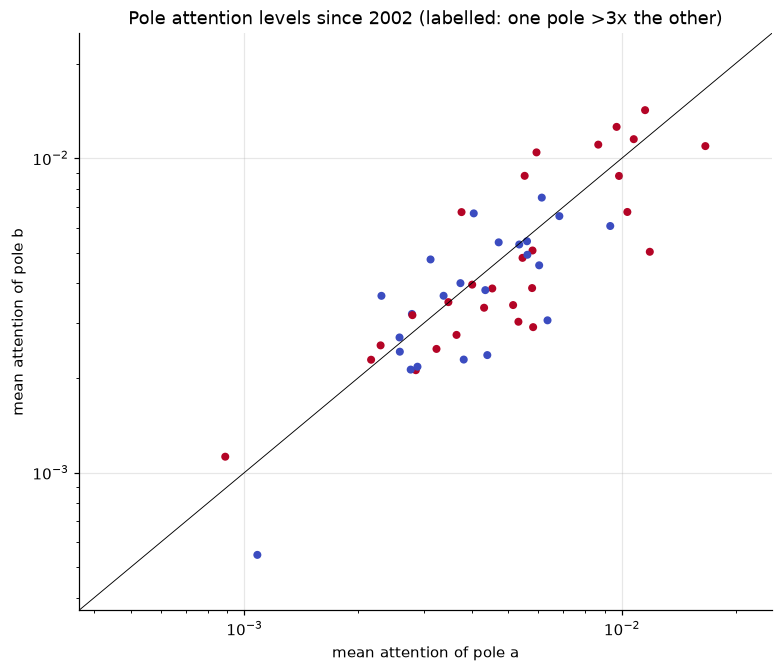

In [4]:
FILES = sorted(ART.path.glob("[12][0-9][0-9][0-9]-[01][0-9].parquet"))
daily = (pl.scan_parquet([str(f) for f in FILES]).filter(pl.col("SENTIMENT") == "all")
         .select("DATE", "reservoir", "dimension", "narrative", "pole", KEY, "SUPPORT", "TOTAL_SCORE", "N_HEADLINES")
         .with_columns(pl.when(pl.col("N_HEADLINES") > 0)
                       .then(pl.col("TOTAL_SCORE").fill_null(0.0) / pl.col("N_HEADLINES")).alias("THETA"))
         .collect())
NARR = daily.select("reservoir", "dimension", "narrative", "pole", KEY).unique(KEY).sort(KEY)
missing = set(PAIRS["key_a"]) | set(PAIRS["key_b"])
missing -= set(NARR[KEY])
assert not missing, f"pair keys not in the panel: {sorted(missing)}"
LAST_DAY = daily["DATE"].max()
print(f"panel {daily['DATE'].min()} .. {LAST_DAY}, {NARR.height} narratives; all {2 * PAIRS.height} pole keys found")

lvl = (daily.filter(pl.col("DATE") >= CORR_FROM).group_by(KEY).agg(pl.col("THETA").mean().alias("mean_theta"),
                                                                    (pl.col("SUPPORT") > 0).mean().alias("active")))
PAIRS = (PAIRS.join(lvl.rename({KEY: "key_a", "mean_theta": "theta_a", "active": "active_a"}), on="key_a")
         .join(lvl.rename({KEY: "key_b", "mean_theta": "theta_b", "active": "active_b"}), on="key_b"))
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(PAIRS["theta_a"], PAIRS["theta_b"], s=18, c=PAIRS["valence"].cast(int), cmap="coolwarm")
lim = [min(PAIRS["theta_a"].min(), PAIRS["theta_b"].min()) / 1.5, max(PAIRS["theta_a"].max(), PAIRS["theta_b"].max()) * 1.5]
ax.plot(lim, lim, color="k", lw=0.6); ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(lim); ax.set_ylim(lim)
for r in PAIRS.iter_rows(named=True):
    if (max(r["theta_a"], r["theta_b"]) + EPS) / (min(r["theta_a"], r["theta_b"]) + EPS) > 3:
        ax.annotate(r["pair"].split(":")[1], (r["theta_a"], r["theta_b"]), fontsize=6)
ax.set_xlabel("mean attention of pole a"); ax.set_ylabel("mean attention of pole b")
ax.set_title("Pole attention levels since 2002 (labelled: one pole >3x the other)")
plt.show()

## 2. H1: co-movement of the two poles over time

Weekly attention (Mon–Fri mean) per narrative. Correlations are computed on three transforms:

* **level**: log attention (dominated by slow trends and feed changes);
* **Δ**: weekly change in attention, which is where "the topic got hot" shows up;
* **Δ deseasonalised**: Δ after subtracting the prior-years week-of-year mean (stage 1 of the GFC notebook).

Benchmarks for the same transforms:

* **same-dimension non-pairs**: every other pair of narratives in the same dimension (same topic
  area, but not antonyms). This is the key comparison. If pole pairs co-move *more* than these,
  the scorer is tracking the shared topic.
* **random cross-reservoir pairs**: the common, compositional component.

level (log)       : 1253 complete weeks
Δ                 : 1252 complete weeks
Δ deseasonalised  : 1252 complete weeks
benchmarks: 858 same-dimension non-pairs, 79134 cross-reservoir pairs


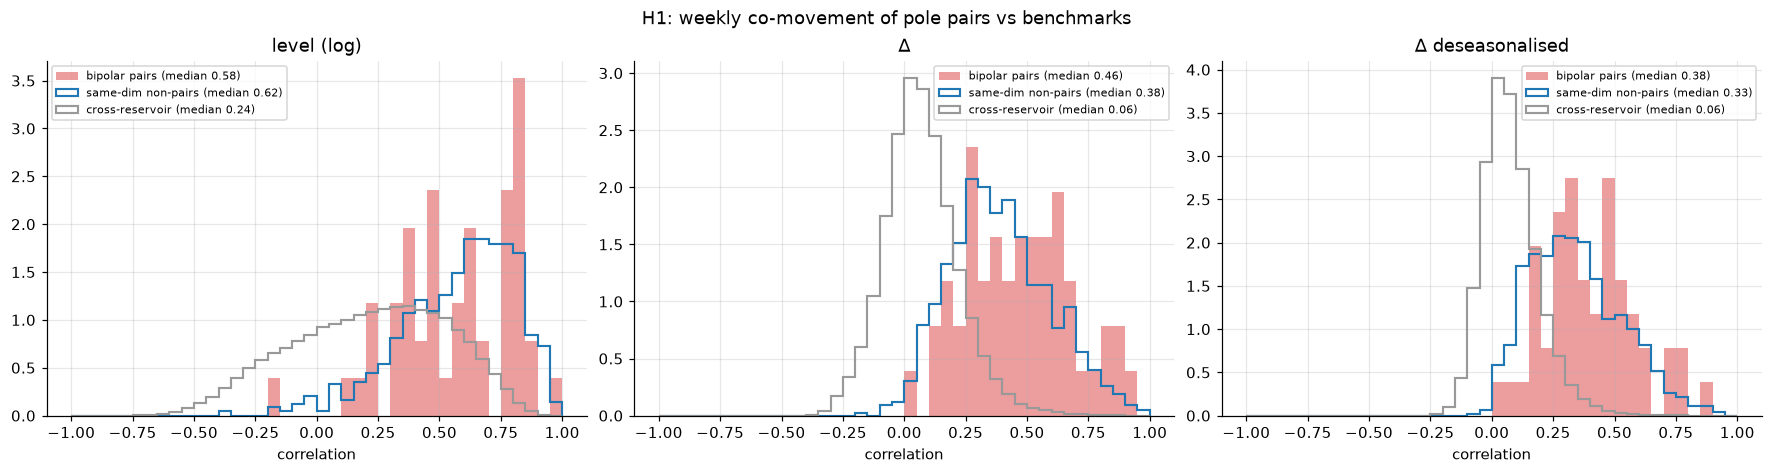

transform,set,n,median,p25,p75,share>0.5
str,str,i64,f64,f64,f64,f64
"""level (log)""","""bipolar pairs""",51,0.576,0.392,0.789,0.569
"""level (log)""","""same-dim non-pairs""",858,0.621,0.433,0.753,0.671
"""level (log)""","""cross-reservoir""",79134,0.238,-0.013,0.461,0.209
"""Δ""","""bipolar pairs""",51,0.459,0.288,0.631,0.451
"""Δ""","""same-dim non-pairs""",858,0.376,0.244,0.523,0.277
"""Δ""","""cross-reservoir""",79134,0.06,-0.027,0.157,0.009
"""Δ deseasonalised""","""bipolar pairs""",51,0.38,0.264,0.506,0.275
"""Δ deseasonalised""","""same-dim non-pairs""",858,0.325,0.199,0.471,0.212
"""Δ deseasonalised""","""cross-reservoir""",79134,0.064,0.001,0.141,0.004


In [5]:
def deseasonalise(d):
    # prior-years-only week-of-year mean, expanding (as in the GFC/Covid notebooks)
    d = d.with_columns(pl.col("DATE").dt.iso_year().alias("YEAR"), pl.col("DATE").dt.week().clip(1, 52).alias("WOY"))
    yw = (d.group_by(KEY, "YEAR", "WOY").agg(pl.col("THETA").mean().alias("YW")).sort(KEY, "WOY", "YEAR")
          .with_columns(pl.col("YW").fill_null(0.0).cum_sum().shift(1).over(KEY, "WOY").alias("_s"),
                        pl.col("YW").is_not_null().cast(pl.Int32).cum_sum().shift(1).over(KEY, "WOY").alias("_n"))
          .with_columns(pl.when(pl.col("_n") >= 1).then(pl.col("_s") / pl.col("_n")).alias("SEAS"))
          .select(KEY, "YEAR", "WOY", "SEAS"))
    return d.join(yw, on=[KEY, "YEAR", "WOY"], how="left").with_columns((pl.col("THETA") - pl.col("SEAS")).alias("THETA_DS"))


wk = (deseasonalise(daily).filter(pl.col("DATE").dt.weekday() <= 5)
      .with_columns((pl.col("DATE").dt.truncate("1w") + timedelta(days=4)).alias("WEEK"))
      .group_by(KEY, "WEEK").agg(pl.col("THETA").mean(), pl.col("THETA_DS").mean())
      .filter(pl.col("WEEK") >= CORR_FROM).sort("WEEK"))
KEYS = NARR[KEY].to_list()
kidx = {k: i for i, k in enumerate(KEYS)}


def wide(col):
    w = wk.pivot(on=KEY, index="WEEK", values=col).sort("WEEK")
    return w["WEEK"], w.select(KEYS).to_numpy()


WEEKS, TH = wide("THETA")
_, THDS = wide("THETA_DS")
TRANSFORMS = {"level (log)": np.log(TH + EPS), "Δ": np.diff(TH, axis=0), "Δ deseasonalised": np.diff(THDS, axis=0)}


def corr_matrix(X):
    X = X[~np.isnan(X).any(axis=1)]
    return np.corrcoef(X.T), X.shape[0]


CORR = {}
for name, X in TRANSFORMS.items():
    CORR[name], n = corr_matrix(X)
    print(f"{name:18s}: {n} complete weeks")

res_of = dict(zip(NARR[KEY], NARR["reservoir"])); dim_of = dict(zip(NARR[KEY], NARR["reservoir"] + "|" + NARR["dimension"]))
pair_set = {frozenset((a, b)) for a, b in zip(PAIRS["key_a"], PAIRS["key_b"])}
iu = np.triu_indices(len(KEYS), 1)
same_dim = [(i, j) for i, j in zip(*iu) if dim_of[KEYS[i]] == dim_of[KEYS[j]]
            and frozenset((KEYS[i], KEYS[j])) not in pair_set]
cross_res = [(i, j) for i, j in zip(*iu) if res_of[KEYS[i]] != res_of[KEYS[j]]]
pidx = [(kidx[a], kidx[b]) for a, b in zip(PAIRS["key_a"], PAIRS["key_b"])]
print(f"benchmarks: {len(same_dim)} same-dimension non-pairs, {len(cross_res)} cross-reservoir pairs")


def vals(C, ij):
    ij = np.array(ij)
    return C[ij[:, 0], ij[:, 1]]


fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
summary = []
for ax, name in zip(axes, TRANSFORMS):
    C = CORR[name]
    groups = {"bipolar pairs": vals(C, pidx), "same-dim non-pairs": vals(C, same_dim), "cross-reservoir": vals(C, cross_res)}
    bins = np.linspace(-1, 1, 41)
    for (lab, v), col in zip(groups.items(), ("tab:red", "tab:blue", "0.6")):
        ax.hist(v, bins=bins, density=True, histtype="step" if lab != "bipolar pairs" else "stepfilled",
                alpha=0.45 if lab == "bipolar pairs" else 1, color=col, lw=1.4, label=f"{lab} (median {np.median(v):.2f})")
        summary.append({"transform": name, "set": lab, "n": len(v), "median": np.median(v),
                        "p25": np.percentile(v, 25), "p75": np.percentile(v, 75), "share>0.5": (v > 0.5).mean()})
    ax.set_title(name); ax.legend(fontsize=7); ax.set_xlabel("correlation")
fig.suptitle("H1: weekly co-movement of pole pairs vs benchmarks")
plt.show()
pl.DataFrame(summary).with_columns(pl.selectors.float().round(3))

In [6]:
# per pair: Δ correlation and its percentile within the same-dimension non-pair distribution
C = CORR["Δ"]; Cds = CORR["Δ deseasonalised"]; Cl = CORR["level (log)"]
sd_vals = np.sort(vals(C, same_dim))
pair_corr = PAIRS.with_columns(
    pl.Series("corr_level", [Cl[i, j] for i, j in pidx]),
    pl.Series("corr_d", [C[i, j] for i, j in pidx]),
    pl.Series("corr_d_ds", [Cds[i, j] for i, j in pidx]),
    pl.Series("pctl_vs_same_dim", [np.searchsorted(sd_vals, C[i, j]) / len(sd_vals) for i, j in pidx]),
    # median Δ-corr of each pole with the OTHER narratives of its own dimension (its topic neighbours)
    pl.Series("corr_d_neighbours", [np.nanmedian([C[i, kidx[k]] for k in KEYS if dim_of[k] == dim_of[KEYS[i]]
                                                  and k not in (KEYS[i], KEYS[j])] or [np.nan]) for i, j in pidx]),
).sort("corr_d", descending=True)
pair_corr.select("pair", "a", "b", "corr_level", "corr_d", "corr_d_ds", "pctl_vs_same_dim",
                 "corr_d_neighbours").with_columns(pl.selectors.float().round(2))

pair,a,b,corr_level,corr_d,corr_d_ds,pctl_vs_same_dim,corr_d_neighbours
str,str,str,f64,f64,f64,f64,f64
"""issuer-profitability:earnings""","""earnings-beat""","""earnings-miss""",0.86,0.9,0.71,0.99,0.69
"""political-power-tenure:mandate""","""mandate-strengthening""","""mandate-weakening""",0.76,0.9,0.87,0.99,0.71
"""labour-market-slack:labour-market""","""labour-market-slackening""","""labour-market-tightening""",0.64,0.89,0.79,0.99,0.7
"""aggregate-output-and-cycle:productivity""","""productivity-acceleration""","""productivity-slowdown""",0.82,0.83,0.73,0.98,0.47
"""cross-border-monetary-conditions:global-liquidity""","""global-liquidity-easing""","""global-liquidity-tightening""",0.97,0.82,0.77,0.98,0.53
"""issuer-profitability:margin""","""margin-expansion""","""margin-compression""",0.6,0.76,0.56,0.95,0.75
"""intermediation-capacity:bank-balance-sheet""","""bank-balance-sheet-repair""","""bank-balance-sheet-impairment""",0.8,0.72,0.61,0.94,0.5
"""issuer-profitability:revenue""","""revenue-beat""","""revenue-miss""",0.66,0.67,0.47,0.9,0.71
"""sector-demand-condition:pricing-power""","""pricing-power-expansion""","""pricing-power-erosion""",0.58,0.67,0.49,0.9,0.25


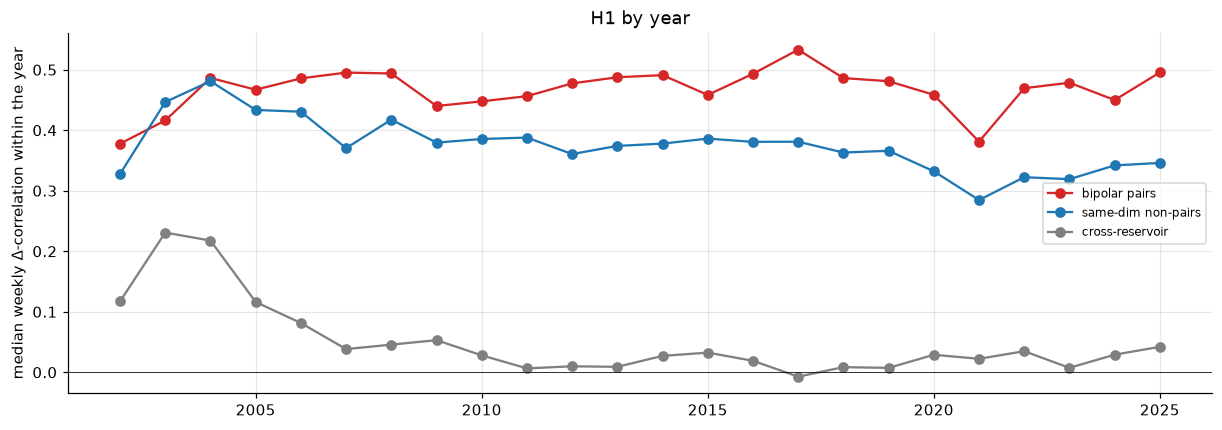

In [7]:
# does the co-movement depend on the period? yearly Δ-correlations, medians per set
years = np.array([w.year for w in WEEKS.to_list()[1:]])
X = TRANSFORMS["Δ"]
yr_rows = []
for y in np.unique(years):
    m = (years == y)
    Xm = X[m]
    Xm = Xm[~np.isnan(Xm).any(axis=1)]
    if Xm.shape[0] < 30:
        continue
    Cy = np.corrcoef(Xm.T)
    yr_rows.append({"year": int(y), "bipolar pairs": np.nanmedian(vals(Cy, pidx)),
                    "same-dim non-pairs": np.nanmedian(vals(Cy, same_dim)),
                    "cross-reservoir": np.nanmedian(vals(Cy, cross_res[::7]))})
yr = pl.DataFrame(yr_rows)
fig, ax = plt.subplots(figsize=(11, 3.8))
for c, col in zip(("bipolar pairs", "same-dim non-pairs", "cross-reservoir"), ("tab:red", "tab:blue", "0.5")):
    ax.plot(yr["year"], yr[c], marker="o", color=col, label=c)
ax.axhline(0, color="k", lw=0.5); ax.set_ylabel("median weekly Δ-correlation within the year"); ax.legend(fontsize=8)
ax.set_title("H1 by year")
plt.show()

## 3. H2: does the pole balance tilt the right way in known-direction episodes?

Balance of a pair = log(θ_up + ε) − log(θ_down + ε) on weekly attention, where "up" is the
pole that should gain in the episode. Tilt = mean balance in the episode − mean balance in the
`EPISODE_BASELINE_WEEKS` before it. `p` comes from a moving-block bootstrap over the baseline:
the share of baseline blocks, each as long as the episode, whose mean is at least as far above
the baseline mean. **The episodes were listed before running**; all are reported, failures
included. Episodes that run past the end of the panel are skipped.

In [8]:
wk_arr = np.array(WEEKS.to_list())
ep_rows = []
for up_, down_, s, e in EPISODES:
    if e > LAST_DAY:
        print(f"skipped (panel ends {LAST_DAY}): {up_} vs {down_} {s}..{e}")
        continue
    ku = NARR.filter(pl.col("narrative") == up_)[KEY].to_list()
    kd = NARR.filter(pl.col("narrative") == down_)[KEY].to_list()
    pr = PAIRS.filter(pl.col("key_a").is_in(ku + kd) & pl.col("key_b").is_in(ku + kd))
    assert pr.height == 1, (up_, down_)
    iu_, id_ = kidx[[k for k in ku if k in (pr["key_a"][0], pr["key_b"][0])][0]], kidx[[k for k in kd if k in (pr["key_a"][0], pr["key_b"][0])][0]]
    bal = np.log(TH[:, iu_] + EPS) - np.log(TH[:, id_] + EPS)
    in_ep = (wk_arr >= s) & (wk_arr <= e)
    i0 = np.flatnonzero(in_ep)[0]
    base = bal[max(0, i0 - EPISODE_BASELINE_WEEKS):i0]
    base = base[~np.isnan(base)]
    L = int(in_ep.sum())
    tilt = np.nanmean(bal[in_ep]) - base.mean()
    blocks = np.array([base[k:k + L].mean() for k in range(0, max(1, len(base) - L + 1))]) - base.mean()
    p = (1 + (blocks >= tilt).sum()) / (len(blocks) + 1)
    ep_rows.append({"episode": f"{s:%Y-%m}..{e:%Y-%m}", "up": up_, "down": down_, "tilt": float(tilt),
                    "right_direction": bool(tilt > 0), "p_block": float(p), "weeks": L, "baseline_weeks": len(base),
                    "share_up_before": float(np.nanmean((TH[:, iu_] / (TH[:, iu_] + TH[:, id_]))[max(0, i0 - EPISODE_BASELINE_WEEKS):i0])),
                    "share_up_during": float(np.nanmean((TH[:, iu_] / (TH[:, iu_] + TH[:, id_]))[in_ep]))})
EP = pl.DataFrame(ep_rows)
print(f"right direction: {EP['right_direction'].sum()}/{EP.height};  right direction and p<0.05: "
      f"{(EP['right_direction'] & (EP['p_block'] < 0.05)).sum()}/{EP.height}")
EP.with_columns(pl.selectors.float().round(3))

right direction: 22/27;  right direction and p<0.05: 16/27


episode,up,down,tilt,right_direction,p_block,weeks,baseline_weeks,share_up_before,share_up_during
str,str,str,f64,bool,f64,i64,i64,f64,f64
"""2007-07..2009-06""","""housing-bust""","""housing-boom""",0.295,true,0.5,104,104,0.497,0.57
"""2007-08..2009-03""","""bank-balance-sheet-impairment""","""bank-balance-sheet-repair""",0.234,true,0.053,87,104,0.513,0.571
"""2007-08..2009-06""","""credit-supply-tightening""","""credit-supply-expansion""",0.048,true,0.167,100,104,0.518,0.53
"""2008-09..2009-06""","""rating-downgrade""","""rating-upgrade""",0.249,true,0.016,43,104,0.603,0.661
"""2008-09..2009-03""","""credit-deterioration""","""credit-strengthening""",-0.085,false,1.0,30,104,0.565,0.544
"""2008-09..2009-03""","""credit-spread-plumbing-widening""","""credit-spread-plumbing-tightening""",-0.102,false,1.0,30,104,0.635,0.611
"""2008-09..2009-06""","""business-cycle-contraction""","""business-cycle-expansion""",0.317,true,0.016,43,104,0.45,0.528
"""2008-10..2009-12""","""labour-market-slackening""","""labour-market-tightening""",0.051,true,0.024,65,104,0.563,0.575
"""2008-10..2009-06""","""global-liquidity-easing""","""global-liquidity-tightening""",0.0,true,0.433,39,104,0.517,0.517


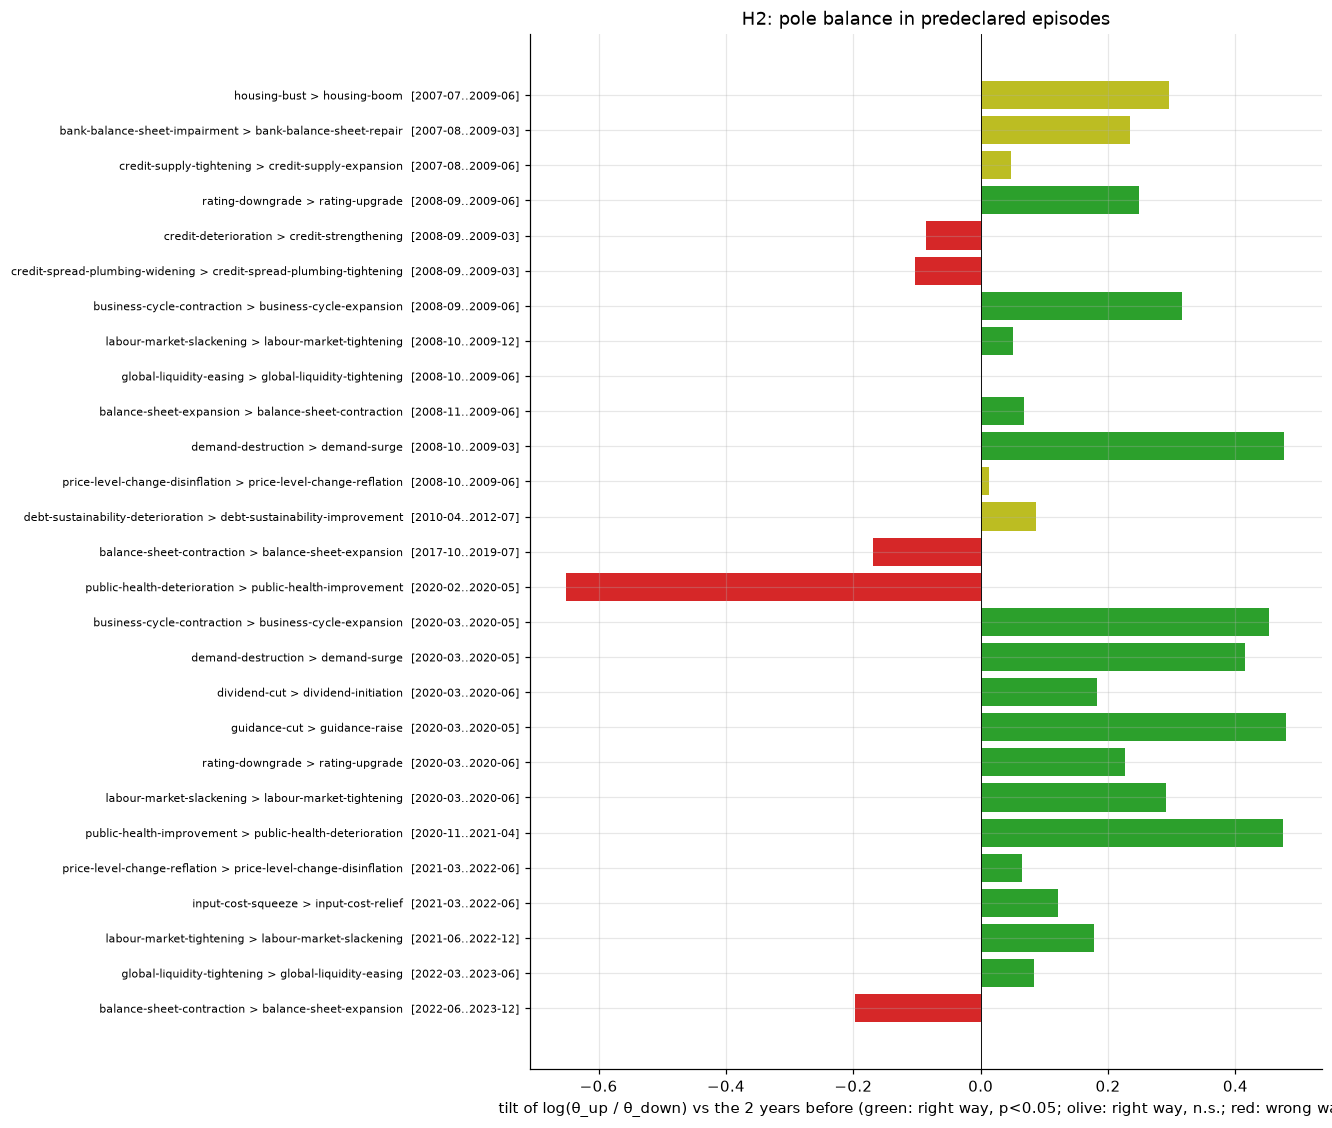

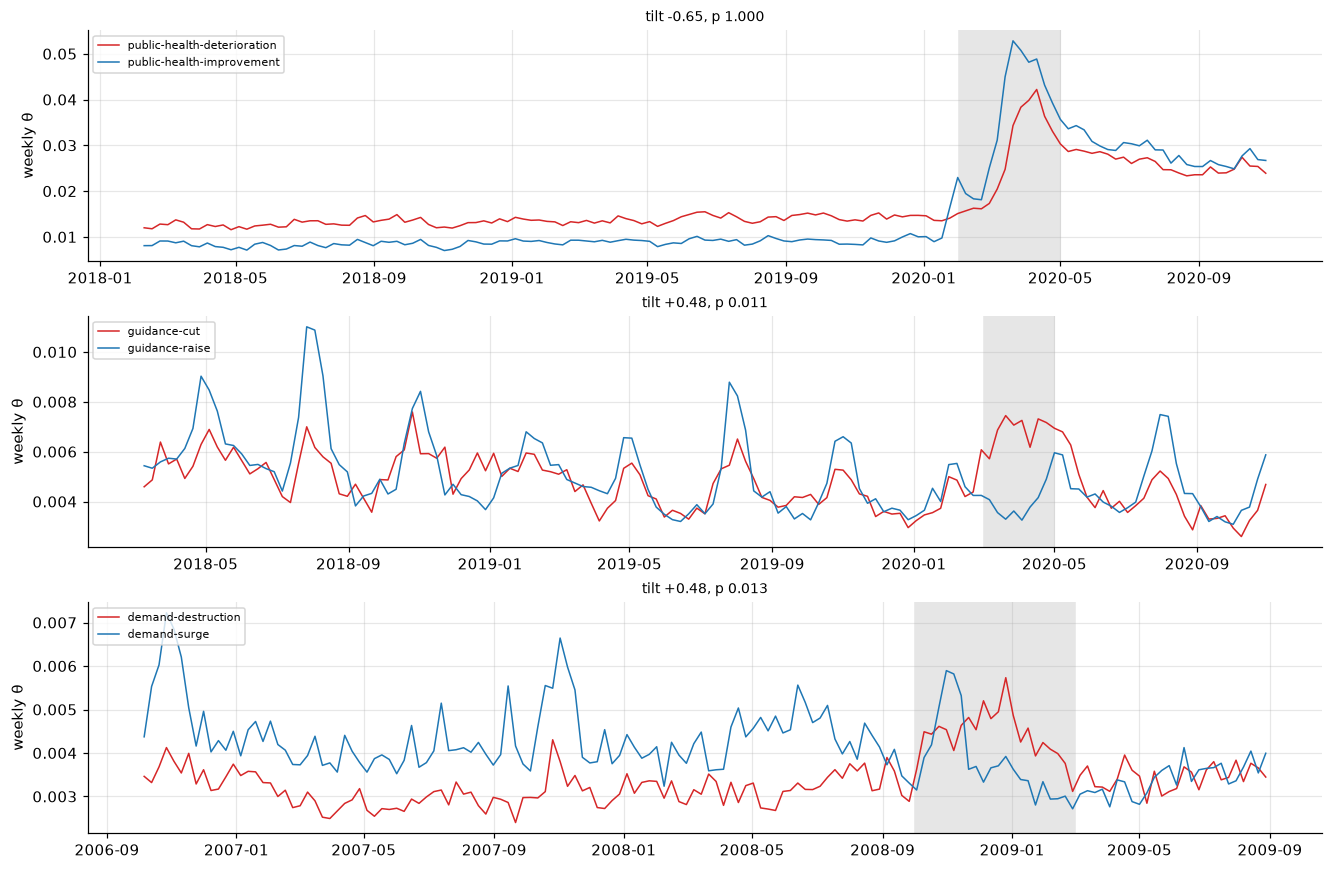

In [9]:
fig, ax = plt.subplots(figsize=(12, 0.32 * EP.height + 1.5))
y = np.arange(EP.height)
cols = ["tab:green" if (r and p < 0.05) else ("tab:olive" if r else "tab:red")
        for r, p in zip(EP["right_direction"], EP["p_block"])]
ax.barh(y, EP["tilt"], color=cols)
ax.set_yticks(y, [f"{u} > {d}  [{e}]" for u, d, e in zip(EP["up"], EP["down"], EP["episode"])], fontsize=7)
ax.axvline(0, color="k", lw=0.6); ax.invert_yaxis()
ax.set_xlabel("tilt of log(θ_up / θ_down) vs the 2 years before (green: right way, p<0.05; olive: right way, n.s.; red: wrong way)")
ax.set_title("H2: pole balance in predeclared episodes")
plt.show()

# the attention shares behind three episodes, to see what a 'tilt' looks like in the raw data
show = EP.sort("tilt").head(1).vstack(EP.sort("tilt", descending=True).head(2))
fig, axes = plt.subplots(show.height, 1, figsize=(12, 2.6 * show.height))
for ax, r in zip(np.atleast_1d(axes), show.iter_rows(named=True)):
    s, e = [date.fromisoformat(x + "-01") for x in r["episode"].split("..")]
    ku = NARR.filter(pl.col("narrative") == r["up"])[KEY][0]; kd = NARR.filter(pl.col("narrative") == r["down"])[KEY][0]
    m = (wk_arr >= s - timedelta(weeks=EPISODE_BASELINE_WEEKS)) & (wk_arr <= e + timedelta(weeks=26))
    ax.plot(wk_arr[m], TH[m, kidx[ku]], color="tab:red", lw=1, label=r["up"])
    ax.plot(wk_arr[m], TH[m, kidx[kd]], color="tab:blue", lw=1, label=r["down"])
    ax.axvspan(s, e, color="0.9"); ax.legend(fontsize=7, loc="upper left"); ax.set_ylabel("weekly θ")
    ax.set_title(f"tilt {r['tilt']:+.2f}, p {r['p_block']:.3f}", fontsize=9)
plt.show()

## 4. H3: are the poles separated in the scorer's own geometry?

One unit vector per primitive, computed exactly as in the monthly tau job
(`representative_matrix`: R2-corrected texts, averaged, renormalised), with the latest mu row used
by the run. A narrative's prototype is the normalised mean of its primitives. The comparisons:

* **cos(prototype a, prototype b)** vs the same cosine for same-dimension non-pairs;
* **nearest-foreign-primitive test**: for each primitive of a pole, is its nearest primitive
  *outside its own narrative* in the sibling pole? The chance level is the sibling's share of
  foreign primitives in the same dimension.

reference mu row: 2025-12-31; 1508 primitives, 419 narratives


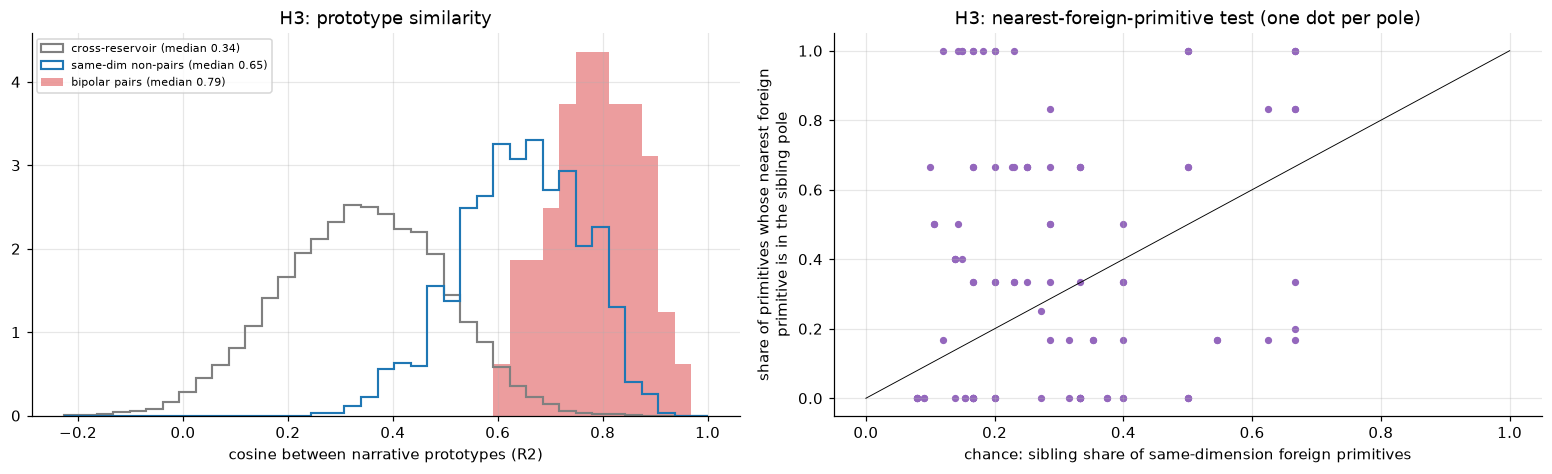

poles whose nearest-foreign share exceeds chance: 54/102; median nn_in_sibling 0.33 vs median chance 0.25


In [10]:
table = load_registered_table(TAX_ART, CFG.paraphrase_style.value, include_master=CFG.include_master)
# the exact primitive-text embeddings the run used: the cache file named by its recorded provenance
# (texts digest + embedder identity); no embedding server is contacted
PE = RUN_META["embeddings_provenance"]["primitive_embeddings"]
assert PE["texts_digest"] == texts_digest(table), "taxonomy texts differ from the run's"
cache_file = CACHE_DIR / f"primitive_texts__{PE['texts_digest']}__{PE['identity_digest']}.npy"
assert cache_file.exists(), f"primitive-text embedding cache missing: {cache_file}"
P = l2_normalise(np.load(cache_file))
if embeddings_digest(P) != RUN_META["primitive_embeddings_digest"]:
    print("WARNING: cached primitive embeddings differ bitwise from the run's (same recipe; TEI is not "
          "bit-reproducible). The reproduction check in section 5 decides whether that matters.")
mu_art = next(x for x in (dl, up) if x.exists(RUN_META["mu_asof_id"])).get(RUN_META["mu_asof_id"])
MU_DF = load_reference_series(next(mu_art.path.glob("*.parquet")))
DIAG = (pl.scan_parquet(str(DIAG_ART.path / "*.parquet"))
        .select("DATE", "N_HEADLINES", "TAU", "MU_DATE", "N_EFF").collect().sort("DATE"))
mu_ref = resolve_reference(MU_DF, DIAG["MU_DATE"].drop_nulls().max())
R = representative_matrix(P, table, CFG.mode, mu_ref.mu, mu_ref.mu_hat)          # (n_prim, dim), unit rows
p2n = table.primitive_to_narrative
NF = table.narrative_frame                                                         # has narrative_id, narrative_key
nid_of = dict(zip(NF["narrative_key"], NF["narrative_id"]))
proto = np.stack([R[p2n == i].mean(axis=0) for i in range(table.n_narratives)])
proto /= np.linalg.norm(proto, axis=1, keepdims=True)
PC = proto @ proto.T
print(f"reference mu row: {mu_ref.date}; {table.n_primitives} primitives, {table.n_narratives} narratives")

cos_pair = np.array([PC[nid_of[a], nid_of[b]] for a, b in zip(PAIRS["key_a"], PAIRS["key_b"])])
cos_sd = np.sort(np.array([PC[nid_of[KEYS[i]], nid_of[KEYS[j]]] for i, j in same_dim]))
cos_x = np.array([PC[nid_of[KEYS[i]], nid_of[KEYS[j]]] for i, j in cross_res[::5]])

# nearest foreign primitive
G = R @ R.T
np.fill_diagonal(G, -np.inf)
nn_rows = []
dim_of_nid = {nid_of[k]: dim_of[k] for k in KEYS}
for a, b in zip(PAIRS["key_a"], PAIRS["key_b"]):
    for own, sib in ((a, b), (b, a)):
        io, isb = nid_of[own], nid_of[sib]
        prims = np.flatnonzero(p2n == io)
        foreign = p2n != io
        same_dim_foreign = foreign & np.isin(p2n, [n for n, d in dim_of_nid.items() if d == dim_of[own]])
        nn = np.argmax(np.where(foreign[None, :], G[prims], -np.inf), axis=1)
        nn_rows.append({"key": own, "sibling": sib, "n_prims": len(prims),
                        "nn_in_sibling": float((p2n[nn] == isb).mean()),
                        "chance_in_dimension": float((p2n[same_dim_foreign] == isb).sum() / max(same_dim_foreign.sum(), 1)),
                        "nn_in_same_dimension": float(np.isin(p2n[nn], np.flatnonzero(np.isin(np.arange(table.n_narratives), [n for n, d in dim_of_nid.items() if d == dim_of[own]]))).mean())})
NN = pl.DataFrame(nn_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
bins = np.linspace(min(cos_x.min(), cos_pair.min()) - 0.02, 1, 40)
axes[0].hist(cos_x, bins=bins, density=True, histtype="step", color="0.5", lw=1.4, label=f"cross-reservoir (median {np.median(cos_x):.2f})")
axes[0].hist(cos_sd, bins=bins, density=True, histtype="step", color="tab:blue", lw=1.4, label=f"same-dim non-pairs (median {np.median(cos_sd):.2f})")
axes[0].hist(cos_pair, bins=bins, density=True, alpha=0.45, color="tab:red", label=f"bipolar pairs (median {np.median(cos_pair):.2f})")
axes[0].set_xlabel("cosine between narrative prototypes (R2)"); axes[0].legend(fontsize=7); axes[0].set_title("H3: prototype similarity")
axes[1].scatter(NN["chance_in_dimension"], NN["nn_in_sibling"], s=14, color="tab:purple")
axes[1].plot([0, 1], [0, 1], color="k", lw=0.6)
axes[1].set_xlabel("chance: sibling share of same-dimension foreign primitives")
axes[1].set_ylabel("share of primitives whose nearest foreign\nprimitive is in the sibling pole")
axes[1].set_title("H3: nearest-foreign-primitive test (one dot per pole)")
plt.show()
print(f"poles whose nearest-foreign share exceeds chance: {(NN['nn_in_sibling'] > NN['chance_in_dimension']).sum()}/{NN.height}; "
      f"median nn_in_sibling {NN['nn_in_sibling'].median():.2f} vs median chance {NN['chance_in_dimension'].median():.2f}")

## 5. H4: single headlines (re-scored sample)

The production selection is re-run on `SAMPLE_ROWS` headlines drawn from `SAMPLE_MONTH`, using the same functions
(`apply_mode`, `primitive_scores`, `select`, `headline_narrative_scores`), the run's config, and
for each day **the tau and mu row recorded in `day_diagnostics`**. Kept per headline and per pole:

* whether the pole was retained, and its narrative score;
* the pole's best pooled primitive score (`smax`), whether retained or not;
* RavenPack `EVENT_SENTIMENT_SCORE` (mean over the headline's entities) and the headline text.

**Reproduction check first:** the lowest-volume day of `SAMPLE_MONTH` is re-scored in full and compared with the stored
`narrative_daily` SUPPORT/TOTAL_SCORE. If it fails, nothing below is trustworthy.

In [11]:
hl_art, emb_art = up.latest("ravenpack_headlines"), up.latest("headline_embeddings")
N_CAND = RUN_META["n_candidates"]
p2n_i = table.primitive_to_narrative
POLE_KEYS = list(PAIRS["key_a"]) + list(PAIRS["key_b"])
POLE_NID = np.array([nid_of[k] for k in POLE_KEYS])
POLE_PRIMS = [np.flatnonzero(p2n_i == n) for n in POLE_NID]
_mcache = {}


def scoring_for(mu_date):
    if mu_date not in _mcache:
        _mcache.clear()
        mu = resolve_reference(MU_DF, mu_date)
        _mcache[mu_date] = (mu, scoring_matrix(P, table, CFG.mode, CFG.paraphrase_pooling, mu.mu, mu.mu_hat))
    return _mcache[mu_date]


def month_file(day):
    return f"{day.year}-{day.month:02d}.parquet"


def day_query(day):
    # the production day query (streaming.ParquetHeadlineSource), plus text and ESS
    name = month_file(day)
    hl, emb = hl_art.path / name, emb_art.path / name
    nxt = (day + timedelta(days=1)).isoformat()
    return f'''SELECT h.RP_STORY_ID, h.HEADLINE, list_avg(h.EVENT_SENTIMENT_SCORE) AS ESS,
               CAST(e.EMBEDDING AS FLOAT[{EMBEDDING_DIM}]) AS EMBEDDING
               FROM read_parquet('{hl}') h JOIN read_parquet('{emb}') e USING (RP_STORY_ID)
               WHERE h.TIMESTAMP_UTC >= '{day.isoformat()}' AND h.TIMESTAMP_UTC < '{nxt}'
               ORDER BY h.RP_STORY_ID'''


def month_sample_query(month, n):
    # n stories drawn uniformly over one month (deterministic hash), with their day
    name = f"{month}.parquet"
    hl, emb = hl_art.path / name, emb_art.path / name
    return f'''WITH s AS (SELECT DISTINCT RP_STORY_ID FROM read_parquet('{hl}')
                          ORDER BY hash(RP_STORY_ID || '{SAMPLE_SEED}') LIMIT {int(n)})
               SELECT h.RP_STORY_ID, h.HEADLINE, CAST(substr(h.TIMESTAMP_UTC, 1, 10) AS DATE) AS DATE,
                      list_avg(h.EVENT_SENTIMENT_SCORE) AS ESS,
                      CAST(e.EMBEDDING AS FLOAT[{EMBEDDING_DIM}]) AS EMBEDDING
               FROM read_parquet('{hl}') h JOIN s USING (RP_STORY_ID) JOIN read_parquet('{emb}') e USING (RP_STORY_ID)
               ORDER BY DATE, h.RP_STORY_ID'''


def fetch(sql):
    con = duckdb.connect()
    try:
        con.execute(f"SET threads={DUCKDB_THREADS}"); con.execute("SET enable_progress_bar=false")
        tbl = con.sql(sql).fetch_arrow_table()
    finally:
        con.close()
    tbl = tbl.combine_chunks()
    X = arrow_embeddings_to_numpy(tbl.column("EMBEDDING")) if tbl.num_rows else np.zeros((0, EMBEDDING_DIM), np.float32)
    meta = pl.from_arrow(tbl.drop(["EMBEDDING"]))
    return meta, X


def score_block(X, tau, mu_date):
    # production selection on one block: retained (row, narrative, score) + per-pole smax
    mu, Pm = scoring_for(mu_date)
    tau32 = float(np.float32(tau))
    out_r, out_n, out_s, smax = [], [], [], []
    for i in range(0, X.shape[0], CHUNK):
        H = apply_mode(X[i:i + CHUNK], CFG.mode, mu.mu, mu.mu_hat)
        S = primitive_scores(H, Pm, table.n_primitives, table.n_texts, CFG.paraphrase_pooling)
        sel = select(S, tau32, N_CAND, jump_cut=CFG.jump_cut, jump_min_candidates=CFG.jump_min_candidates)
        r, n, s = headline_narrative_scores(sel.rows, sel.cols, sel.vals, p2n_i, table.n_narratives, CFG.narrative_agg)
        out_r.append(r + i); out_n.append(n); out_s.append(s)
        smax.append(np.stack([S[:, pr].max(axis=1) for pr in POLE_PRIMS], axis=1).astype(np.float32))
    cat = lambda xs, dt: np.concatenate(xs).astype(dt) if xs else np.zeros(0, dt)
    return (cat(out_r, np.int64), cat(out_n, np.int64), cat(out_s, np.float64),
            np.concatenate(smax) if smax else np.zeros((0, len(POLE_PRIMS)), np.float32))


DIAG_BY_DAY = {r["DATE"]: r for r in DIAG.iter_rows(named=True)}

In [12]:
# --- reproduction check: the lowest-volume day of SAMPLE_MONTH re-scored in full vs narrative_daily ---
_y, _m = map(int, SAMPLE_MONTH.split("-"))
cand = DIAG.filter((pl.col("DATE").dt.year() == _y) & (pl.col("DATE").dt.month() == _m)
                   & pl.col("TAU").is_not_null()).sort("N_HEADLINES")
REPRO_DAY = cand["DATE"][0]
d = DIAG_BY_DAY[REPRO_DAY]
meta, X = fetch(day_query(REPRO_DAY))
r_, n_, s_, _ = score_block(X, d["TAU"], d["MU_DATE"])
mine = (pl.DataFrame({"narrative_id": n_, "s": s_}).group_by("narrative_id")
        .agg(pl.len().alias("SUPPORT_re"), pl.col("s").sum().alias("TOTAL_re")))
stored = (daily.filter(pl.col("DATE") == REPRO_DAY).select(KEY, "SUPPORT", "TOTAL_SCORE", "N_HEADLINES")
          .with_columns(pl.col(KEY).replace_strict(nid_of).alias("narrative_id"))
          .join(mine, on="narrative_id", how="left").with_columns(pl.col("SUPPORT_re").fill_null(0), pl.col("TOTAL_re").fill_null(0.0)))
n_sup_diff = int((stored["SUPPORT"] != stored["SUPPORT_re"]).sum())
tot_err = (stored["TOTAL_SCORE"].fill_null(0) - stored["TOTAL_re"]).abs()
max_tot = float(tot_err.max())
tot_ok = bool((tot_err <= 1e-6 * stored["TOTAL_SCORE"].fill_null(0).abs() + 1e-3).all())   # summation order only
print(f"{REPRO_DAY}: {X.shape[0]} headlines re-scored vs N_HEADLINES stored {stored['N_HEADLINES'][0]}; "
      f"narratives with a different SUPPORT: {n_sup_diff}; max |ΔTOTAL_SCORE| {max_tot:.2e}")
assert X.shape[0] == stored["N_HEADLINES"][0] and n_sup_diff == 0 and tot_ok, \
    "re-scoring does not reproduce the production panel: stop and investigate before reading section 5"
print("REPRODUCTION OK: the sample below uses the production selection exactly")

/tmp/ipykernel_978025/1967535987.py:51: DeprecationWarning: fetch_arrow_table() is deprecated, use to_arrow_table() instead.
  tbl = con.sql(sql).fetch_arrow_table()


2019-05-05: 58061 headlines re-scored vs N_HEADLINES stored 58061; narratives with a different SUPPORT: 0; max |ΔTOTAL_SCORE| 1.63e-06
REPRODUCTION OK: the sample below uses the production selection exactly


In [13]:
# --- the sample (cached) --------------------------------------------------------------------------
tag = hashlib.blake2b(json.dumps([ART.artifact_id, SAMPLE_MONTH, SAMPLE_ROWS, SAMPLE_SEED, POLE_KEYS]).encode(),
                      digest_size=6).hexdigest()
cmeta, cnpz = CACHE_DIR / f"polar_sample__{tag}.parquet", CACHE_DIR / f"polar_sample__{tag}.npz"
if cmeta.exists() and cnpz.exists():
    SM = pl.read_parquet(cmeta); z = np.load(cnpz); SMAX, RET = z["smax"], z["ret"]
    print("sample loaded from cache:", cmeta.name)
else:
    meta_all, X_all = fetch(month_sample_query(SAMPLE_MONTH, SAMPLE_ROWS))
    ok = np.array([d in DIAG_BY_DAY and DIAG_BY_DAY[d]["TAU"] is not None for d in meta_all["DATE"].to_list()])
    meta_all, X_all = meta_all.filter(pl.Series(ok)), X_all[ok]
    col_of_nid = {n: j for j, n in enumerate(POLE_NID)}
    metas, smaxs, rets = [], [], []
    for day in sorted(set(meta_all["DATE"].to_list())):
        idx = np.flatnonzero((meta_all["DATE"] == day).to_numpy())
        meta, X = meta_all[idx], X_all[idx]
        d = DIAG_BY_DAY[day]
        r_, n_, s_, smax = score_block(X, d["TAU"], d["MU_DATE"])
        ret = np.full((X.shape[0], len(POLE_KEYS)), np.nan, np.float32)
        m = np.isin(n_, POLE_NID)
        ret[r_[m], [col_of_nid[x] for x in n_[m]]] = s_[m]
        n_ret = np.bincount(r_, minlength=X.shape[0]) if r_.size else np.zeros(X.shape[0], int)
        metas.append(meta.with_columns(pl.Series("N_NARR_RETAINED", n_ret)))
        smaxs.append(smax); rets.append(ret)
    print(f"{SAMPLE_MONTH}: {X_all.shape[0]:,} headlines scored over {len(metas)} days", flush=True)
    SM, SMAX, RET = pl.concat(metas), np.concatenate(smaxs), np.concatenate(rets)
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    SM.write_parquet(cmeta); np.savez_compressed(cnpz, smax=SMAX, ret=RET)
TAU_ROW = np.array([DIAG_BY_DAY[d]["TAU"] for d in SM["DATE"].to_list()], np.float32)
ESS = SM["ESS"].to_numpy().astype(float)
print(f"sample: {SM.height:,} headlines over {SM['DATE'].n_unique()} days; ESS available for {np.isfinite(ESS).mean():.0%}; "
      f"headlines touching any pole: {(~np.isnan(RET)).any(axis=1).mean():.1%}")

/tmp/ipykernel_978025/1967535987.py:51: DeprecationWarning: fetch_arrow_table() is deprecated, use to_arrow_table() instead.
  tbl = con.sql(sql).fetch_arrow_table()


2019-05: 200,000 headlines scored over 31 days
sample: 200,000 headlines over 31 days; ESS available for 27%; headlines touching any pole: 56.3%


In [14]:
def auc(pos, neg):
    # P(pos > neg) + 0.5 P(tie), Mann-Whitney
    pos, neg = pos[np.isfinite(pos)], neg[np.isfinite(neg)]
    if len(pos) == 0 or len(neg) == 0:
        return np.nan
    allv = np.concatenate([pos, neg])
    # average ranks (ties share the mean rank)
    _, inv, cnt = np.unique(allv, return_inverse=True, return_counts=True)
    csum = np.cumsum(cnt); avg = csum - (cnt - 1) / 2.0
    ranks = avg[inv]
    return (ranks[:len(pos)].sum() - len(pos) * (len(pos) + 1) / 2) / (len(pos) * len(neg))


npair = PAIRS.height
h_rows = []
for j, r in enumerate(PAIRS.iter_rows(named=True)):
    ra, rb = ~np.isnan(RET[:, j]), ~np.isnan(RET[:, j + npair])
    na, nb, nab = int(ra.sum()), int(rb.sum()), int((ra & rb).sum())
    sa, sb = SMAX[:, j], SMAX[:, j + npair]
    only_a, only_b = ra & ~rb, rb & ~ra
    row = {"pair": r["pair"], "a": r["a"], "b": r["b"], "valence": r["valence"], "n_a": na, "n_b": nb, "n_both": nab,
           "P(b|a)": nab / na if na else np.nan, "P(a|b)": nab / nb if nb else np.nan,
           "lift_b|a": (nab / na) / (nb / SM.height) if na and nb else np.nan,
           # near miss: the sibling clears the absolute tau floor but loses on the top-k budget
           "near_miss_b|a": float((sb[only_a] >= TAU_ROW[only_a]).mean()) if only_a.any() else np.nan,
           "near_miss_a|b": float((sa[only_b] >= TAU_ROW[only_b]).mean()) if only_b.any() else np.nan,
           "median_margin_a": float(np.median(sa[ra] - sb[ra])) if na else np.nan,
           "median_margin_b": float(np.median(sb[rb] - sa[rb])) if nb else np.nan,
           "ESS_a": float(np.nanmean(ESS[only_a])) if only_a.any() else np.nan,
           "ESS_b": float(np.nanmean(ESS[only_b])) if only_b.any() else np.nan,
           "ESS_n": int(np.isfinite(ESS[only_a]).sum() + np.isfinite(ESS[only_b]).sum()),
           "AUC_ESS(a>b)": auc(ESS[only_a], ESS[only_b])}
    h_rows.append(row)
HL = pl.DataFrame(h_rows)
enough = HL.filter((pl.col("n_a") >= MIN_HEADLINES) & (pl.col("n_b") >= MIN_HEADLINES))
print(f"pairs with >= {MIN_HEADLINES} sampled headlines on both poles: {enough.height}/{HL.height}")
HL.with_columns(pl.selectors.float().round(3)).sort("P(b|a)", descending=True, nulls_last=True)

pairs with >= 50 sampled headlines on both poles: 51/51


pair,a,b,valence,n_a,n_b,n_both,P(b|a),P(a|b),lift_b|a,near_miss_b|a,near_miss_a|b,median_margin_a,median_margin_b,ESS_a,ESS_b,ESS_n,AUC_ESS(a>b)
str,str,str,bool,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64
"""political-power-tenure:mandate""","""mandate-strengthening""","""mandate-weakening""",true,8620,10466,5130,0.595,0.49,11.373,0.136,0.227,0.033,0.046,0.138,-0.008,1994,0.619
"""issuer-profitability:earnings""","""earnings-beat""","""earnings-miss""",true,6943,9471,3804,0.548,0.402,11.57,0.191,0.211,0.017,0.061,0.149,0.019,6407,0.59
"""public-health-condition:public-health""","""public-health-improvement""","""public-health-deterioration""",true,5525,8461,2300,0.416,0.272,9.84,0.096,0.08,0.05,0.073,-0.164,-0.009,1756,0.397
"""cross-border-monetary-conditions:global-liquidity""","""global-liquidity-easing""","""global-liquidity-tightening""",false,3106,2891,1045,0.336,0.361,23.275,0.307,0.282,0.049,0.044,0.017,0.006,1759,0.507
"""precious-metal-physical-state:precious-metal-price""","""precious-metal-price-decline""","""precious-metal-price-rise""",false,1348,1343,413,0.306,0.308,45.626,0.211,0.195,0.08,0.066,-0.075,0.161,882,0.309
"""labour-market-slack:labour-market""","""labour-market-slackening""","""labour-market-tightening""",false,2896,2903,846,0.292,0.291,20.126,0.218,0.236,0.066,0.071,-0.064,0.103,1281,0.379
"""inter-state-alignment:diplomatic""","""diplomatic-normalisation""","""diplomatic-rupture""",true,3135,5609,822,0.262,0.147,9.349,0.096,0.086,0.08,0.105,0.129,-0.162,1746,0.699
"""sovereign-solvency-condition:debt-sustainability""","""debt-sustainability-improvement""","""debt-sustainability-deterioration""",true,2574,1999,673,0.261,0.337,26.159,0.322,0.292,0.053,0.043,0.069,-0.007,1753,0.554
"""regulatory-regime-direction:regulatory""","""regulatory-loosening""","""regulatory-tightening""",false,3337,3566,795,0.238,0.223,13.362,0.156,0.169,0.066,0.064,0.063,-0.025,1434,0.558


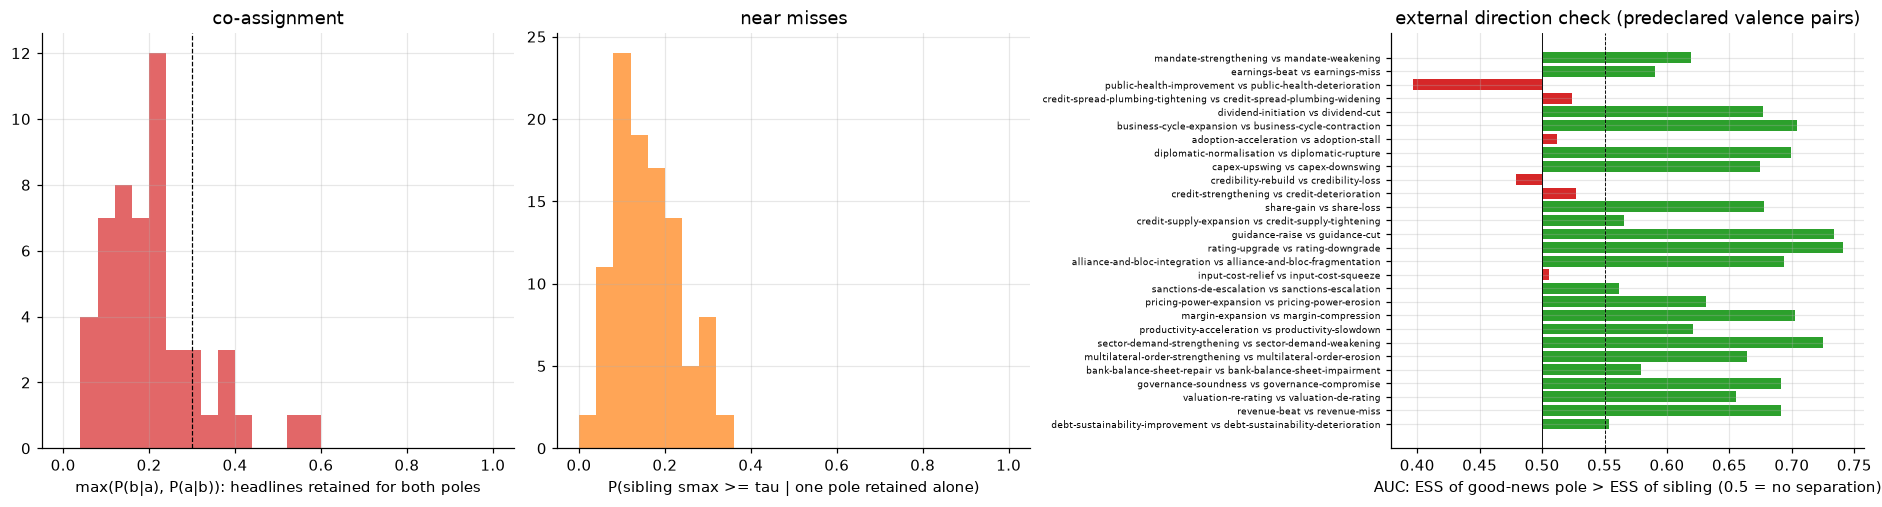

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
e = enough
co = np.maximum(e["P(b|a)"].to_numpy(), e["P(a|b)"].to_numpy())
axes[0].hist(co, bins=np.linspace(0, 1, 26), color="tab:red", alpha=0.7)
axes[0].axvline(FLAG_COASSIGN, color="k", ls="--", lw=0.8)
axes[0].set_xlabel("max(P(b|a), P(a|b)): headlines retained for both poles"); axes[0].set_title("co-assignment")
nm = np.concatenate([e["near_miss_b|a"].to_numpy(), e["near_miss_a|b"].to_numpy()])
axes[1].hist(nm[np.isfinite(nm)], bins=np.linspace(0, 1, 26), color="tab:orange", alpha=0.7)
axes[1].set_xlabel("P(sibling smax >= tau | one pole retained alone)"); axes[1].set_title("near misses")
v = e.filter(pl.col("valence") & (pl.col("ESS_n") >= MIN_HEADLINES))
axes[2].barh(np.arange(v.height), v["AUC_ESS(a>b)"] - 0.5, left=0.5, color=["tab:green" if x >= FLAG_AUC else "tab:red" for x in v["AUC_ESS(a>b)"]])
axes[2].set_yticks(np.arange(v.height), [f"{a} vs {b}" for a, b in zip(v["a"], v["b"])], fontsize=6)
axes[2].axvline(0.5, color="k", lw=0.6); axes[2].axvline(FLAG_AUC, color="k", ls="--", lw=0.6)
axes[2].set_xlabel("AUC: ESS of good-news pole > ESS of sibling (0.5 = no separation)")
axes[2].set_title("external direction check (predeclared valence pairs)")
plt.show()

In [16]:
# what co-assigned headlines look like: the 5 pairs with the highest co-assignment, 4 headlines each
show_pairs = enough.with_columns(pl.max_horizontal("P(b|a)", "P(a|b)").alias("co")).sort("co", descending=True).head(5)
ex = []
for r in show_pairs.iter_rows(named=True):
    j = PAIRS["pair"].to_list().index(r["pair"])
    both = np.flatnonzero(~np.isnan(RET[:, j]) & ~np.isnan(RET[:, j + npair]))
    for i in np.random.default_rng(1).choice(both, size=min(4, len(both)), replace=False):
        ex.append({"pair": f"{r['a']} | {r['b']}", "headline": SM["HEADLINE"][int(i)],
                   "score_a": float(RET[i, j]), "score_b": float(RET[i, j + npair]), "ESS": ESS[i]})
pl.Config.set_fmt_str_lengths(110)
pl.DataFrame(ex).with_columns(pl.selectors.float().round(3))

pair,headline,score_a,score_b,ESS
str,str,f64,f64,f64
"""mandate-strengthening | mandate-weakening""","""Odisha, West Bengal election results: Local strategy, national drive help BJP""",0.321,0.327,0.335
"""mandate-strengthening | mandate-weakening""","""Indore: Zeal of voters quite high""",0.382,0.352,NaN
"""mandate-strengthening | mandate-weakening""","""British Labour Party Leader Warms to Referendum -- WSJ""",0.306,0.276,0.446
"""mandate-strengthening | mandate-weakening""","""Polarized Europe Faces Elections After Merkel Slap at Populists""",0.408,0.355,NaN
"""earnings-beat | earnings-miss""","""Walmart beats on earnings in Q1, with US e-commerce up by 37%""",0.287,0.289,0.533
"""earnings-beat | earnings-miss""","""JD.com Announces First Quarter 2019 Results""",0.275,0.273,0.269
"""earnings-beat | earnings-miss""","""Future Retail Ltd. Reports FY2019 Standalone Net Income INR 7.33B Vs Consensus INR 7.23B""",0.326,0.324,0.46
"""earnings-beat | earnings-miss""","""Resideo Technologies, Inc. 2019 Q1 - Results - Earnings Call Slides""",0.3,0.337,0.0
"""public-health-improvement | public-health-deterioration""","""Immunomic Therapeutics to Participate at Sach's 5(th) Annual Immuno-oncology BD&L and Investment Forum""",0.311,0.319,NaN


In [17]:
# ... and headlines retained for exactly one pole of the same pairs, for contrast
ex = []
for r in show_pairs.iter_rows(named=True):
    j = PAIRS["pair"].to_list().index(r["pair"])
    for col, other, lab in ((j, j + npair, r["a"]), (j + npair, j, r["b"])):
        alone = np.flatnonzero(~np.isnan(RET[:, col]) & np.isnan(RET[:, other]))
        for i in np.random.default_rng(2).choice(alone, size=min(2, len(alone)), replace=False):
            ex.append({"retained_pole": lab, "headline": SM["HEADLINE"][int(i)], "score": float(RET[i, col]), "ESS": ESS[i]})
pl.DataFrame(ex).with_columns(pl.selectors.float().round(3))

retained_pole,headline,score,ESS
str,str,f64,f64
"""mandate-strengthening""","""Lloyd Bell Joins 'Inner Circle' for Plaintiffs Counsel Katheryn Tucker ""Most of the trial advocacy books in my…",0.266,NaN
"""mandate-strengthening""","""Marta Batmasian Joins National Council on White House History""",0.33,NaN
"""mandate-weakening""","""One demoralising sequence encapsulated the Celtics' ugly and bizarre flame-out from the playoffs""",0.27,NaN
"""mandate-weakening""","""New Green MP Paul Manly denies links to 9/11 truther movement after comments resurface""",0.323,NaN
"""earnings-beat""","""--GUIDANCE: (AGN) ALLERGAN PLC Fiscal Year Revenue Range $15.125B - $15.425B""",0.347,0.0
"""earnings-beat""","""I'm a member of both Costco and BJ's. Here's why Costco beats its rival hands down.""",0.301,NaN
"""earnings-miss""","""Codexis Inc. Reports Q1 EBITDA USD -6.50M Vs Consensus USD -5.87M""",0.32,-0.23
"""earnings-miss""","""President Energy PLC FY Results for year ended 31 -2-""",0.304,0.51
"""public-health-improvement""","""Bank of Queensland Limited Directorate Change - EMTN Programme""",0.284,NaN


## 6. Scorecard per pair

One row per pair, with the flags defined in the config cell. A flag means "this evidence points to
topic rather than direction". It is not a significance test, and a pair can be flagged by one
measure and fine on another. `episodes` counts the H2 episodes involving the pair that tilted the
right way.

In [18]:
ep_by_pair = []
for r in PAIRS.iter_rows(named=True):
    sub = EP.filter(pl.col("up").is_in([r["a"], r["b"]]) & pl.col("down").is_in([r["a"], r["b"]]))
    ep_by_pair.append({"pair": r["pair"], "episodes": f"{int(sub['right_direction'].sum())}/{sub.height}" if sub.height else ""})
nn_pair = (NN.with_columns(pl.col("key").alias("key_a")).join(PAIRS.select("pair", "key_a"), on="key_a", how="inner")
           .select("pair", pl.col("nn_in_sibling").alias("nn_a"))
           .join(NN.with_columns(pl.col("key").alias("key_b")).join(PAIRS.select("pair", "key_b"), on="key_b", how="inner")
                 .select("pair", pl.col("nn_in_sibling").alias("nn_b")), on="pair"))
SC = (pair_corr.select("pair", "a", "b", "valence", "corr_d", "pctl_vs_same_dim")
      .join(pl.DataFrame({"pair": PAIRS["pair"], "cos_ab": cos_pair,
                          "cos_pctl_same_dim": [np.searchsorted(cos_sd, c) / len(cos_sd) for c in cos_pair]}), on="pair")
      .join(nn_pair, on="pair")
      .join(HL.select("pair", "n_a", "n_b", pl.max_horizontal("P(b|a)", "P(a|b)").alias("co_assign"),
                      "AUC_ESS(a>b)", "ESS_n"), on="pair")
      .join(pl.DataFrame(ep_by_pair), on="pair")
      .with_columns(
          (pl.col("pctl_vs_same_dim") > FLAG_CORR_PCTL).alias("F_comove"),
          (pl.col("cos_pctl_same_dim") > FLAG_COS_PCTL).alias("F_geometry"),
          pl.when((pl.col("n_a") >= MIN_HEADLINES) & (pl.col("n_b") >= MIN_HEADLINES))
            .then(pl.col("co_assign") > FLAG_COASSIGN).alias("F_coassign"),
          pl.when(pl.col("valence") & (pl.col("ESS_n") >= MIN_HEADLINES))
            .then(pl.col("AUC_ESS(a>b)") < FLAG_AUC).alias("F_no_ESS_sep"))
      .with_columns(pl.sum_horizontal(pl.col("F_comove", "F_geometry", "F_coassign", "F_no_ESS_sep").fill_null(False).cast(pl.Int8))
                    .alias("n_flags"))
      .sort("n_flags", "co_assign", descending=True, nulls_last=True))
SC.with_columns(pl.selectors.float().round(2))

pair,a,b,valence,corr_d,pctl_vs_same_dim,cos_ab,cos_pctl_same_dim,nn_a,nn_b,…,n_b,co_assign,AUC_ESS(a>b),ESS_n,episodes,F_comove,F_geometry,F_coassign,F_no_ESS_sep,n_flags
str,str,str,bool,f64,f64,f32,f64,f64,f64,…,i64,f64,f64,i64,str,bool,bool,bool,bool,i8
"""issuer-profitability:earnings""","""earnings-beat""","""earnings-miss""",true,0.9,0.99,0.81,0.93,0.4,0.4,…,9471,0.55,0.59,6407,"""""",true,true,true,false,3
"""public-health-condition:public-health""","""public-health-improvement""","""public-health-deterioration""",true,0.64,0.86,0.72,0.72,0.17,0.33,…,8461,0.42,0.4,1756,"""1/2""",true,false,true,true,3
"""aggregate-output-and-cycle:productivity""","""productivity-acceleration""","""productivity-slowdown""",true,0.83,0.98,0.86,0.99,1.0,0.17,…,4001,0.37,0.62,3910,"""""",true,true,true,false,3
"""cross-border-monetary-conditions:global-liquidity""","""global-liquidity-easing""","""global-liquidity-tightening""",false,0.82,0.98,0.93,1.0,1.0,0.0,…,2891,0.36,0.51,1759,"""2/2""",true,true,true,null,3
"""sovereign-solvency-condition:debt-sustainability""","""debt-sustainability-improvement""","""debt-sustainability-deterioration""",true,0.55,0.77,0.95,1.0,1.0,0.83,…,1999,0.34,0.55,1753,"""1/1""",true,true,true,false,3
"""sector-input-and-cost-condition:input-cost""","""input-cost-relief""","""input-cost-squeeze""",true,0.66,0.88,0.89,1.0,0.67,0.33,…,1786,0.15,0.51,1909,"""1/1""",true,true,false,true,3
"""political-power-tenure:mandate""","""mandate-strengthening""","""mandate-weakening""",true,0.9,0.99,0.76,0.83,0.83,0.33,…,10466,0.6,0.62,1994,"""""",true,false,true,false,2
"""payout-policy:dividend""","""dividend-initiation""","""dividend-cut""",true,0.64,0.87,0.67,0.58,0.0,0.0,…,2133,0.37,0.68,2869,"""1/1""",true,false,true,false,2
"""labour-market-slack:labour-market""","""labour-market-slackening""","""labour-market-tightening""",false,0.89,0.99,0.85,0.98,0.0,0.17,…,2903,0.29,0.38,1281,"""3/3""",true,true,false,null,2


flag counts (flagged / evaluable pairs):
  F_comove        23 / 51
  F_geometry      25 / 51
  F_coassign       8 / 51
  F_no_ESS_sep     6 / 28

pairs by number of flags: {0: 15, 1: 16, 2: 14, 3: 6}
H2 episodes in the right direction: 22/27 (p<0.05: 16)


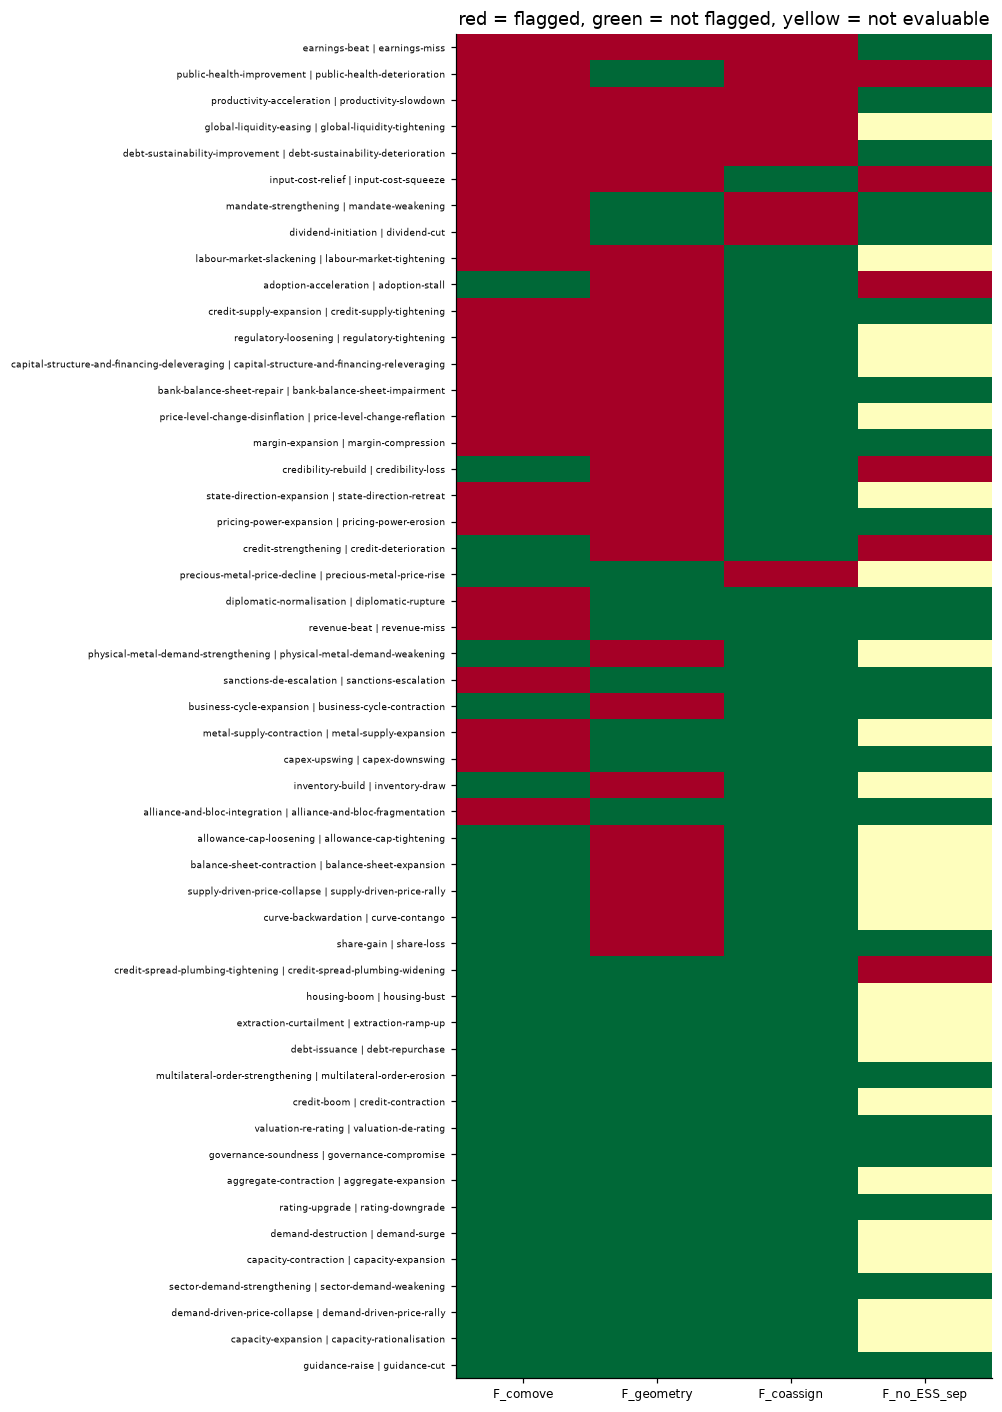

In [19]:
flags = ["F_comove", "F_geometry", "F_coassign", "F_no_ESS_sep"]
counts = {f: (int(SC[f].sum()), int(SC[f].is_not_null().sum())) for f in flags}
print("flag counts (flagged / evaluable pairs):")
for f, (k, n) in counts.items():
    print(f"  {f:14s} {k:3d} / {n}")
print("\npairs by number of flags:", dict(sorted(SC["n_flags"].value_counts().iter_rows())))
print(f"H2 episodes in the right direction: {EP['right_direction'].sum()}/{EP.height} "
      f"(p<0.05: {(EP['right_direction'] & (EP['p_block'] < 0.05)).sum()})")
fig, ax = plt.subplots(figsize=(9, 0.22 * SC.height + 1.5))
M = np.array([[np.nan if v is None else float(v) for v in row] for row in SC.select(flags).rows()])
ax.imshow(np.nan_to_num(M, nan=0.5), aspect="auto", cmap="RdYlGn_r", vmin=0, vmax=1, interpolation="nearest")
ax.set_xticks(range(len(flags)), flags, fontsize=8)
ax.set_yticks(range(SC.height), [f"{a} | {b}" for a, b in zip(SC["a"], SC["b"])], fontsize=6); ax.grid(False)
ax.set_title("red = flagged, green = not flagged, yellow = not evaluable")
plt.show()

## 7. Reading guide

* **H1 vs H3 vs H4 answer different questions.** H1 is about time series: do both poles rise
  when the topic is in the news? H3 is about the taxonomy: are the pole descriptions far apart in
  the corrected embedding space? H4 is about single headlines: does one headline get both labels?
  A pair can pass H4 (headlines rarely get both labels) and still fail H1 (both poles rise
  together because the topic produces news in both directions). That is not an error. It is what
  attention measures.
* **What a pole's attention means in practice.** If H1 flags a pair but H4 does not, the
  headline-level labels are distinct, and pole attention can be read as "news about this topic
  going this way". If H4 flags it too, the scorer cannot tell the poles apart for the same
  headline, and only the topic-level sum is meaningful.
* **ESS is not ground truth.** A low AUC can be RavenPack's classifier, entity-relative scoring,
  or headlines where the pole is right but the entity outcome is mixed. Look at the example
  headlines before drawing conclusions.
* **Sample size and period.** The headline section covers `SAMPLE_ROWS` headlines from
  `SAMPLE_MONTH`. Rare poles fall under `MIN_HEADLINES` and get no headline verdict, and poles whose
  news was scarce that month (e.g. `public-health-*` before 2020) are under-represented. Rerun with
  another month rather than reading their numbers (the cache is keyed by the sample settings).